# MSCS 634 – Lab 5: Clustering Techniques
**Name:** Monalisa Patil  
**Course:** MSCS 634 – Advanced Data Mining  
**Lab Assignment:** Lab 5 – Hierarchical and DBSCAN Clustering on the Wine Dataset

---
## Step 1: Data Preparation and Exploration

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

from scipy.cluster.hierarchy import dendrogram, linkage

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load the Wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print('Dataset shape:', df.shape)
print('\nTarget classes:', wine.target_names)
print('\nClass distribution:')
print(df['target'].value_counts().sort_index())

Dataset shape: (178, 14)

Target classes: ['class_0' 'class_1' 'class_2']

Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


In [3]:
# Examine dataset structure
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [5]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [6]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [7]:
# Standardize the features (exclude the target column)
X = df.drop(columns=['target'])
y_true = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2D with PCA for visualization purposes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Standardized feature matrix shape:', X_scaled.shape)
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.2%}')

Standardized feature matrix shape: (178, 13)
PCA explained variance ratio: [0.36198848 0.1920749 ]
Total variance explained: 55.41%


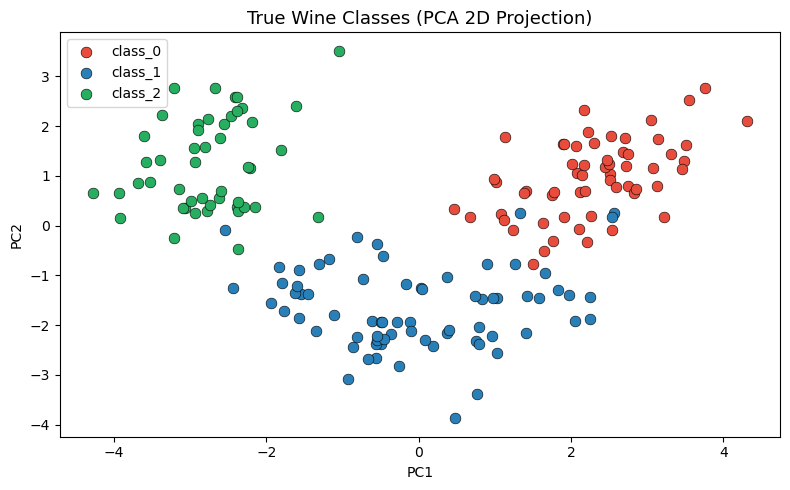

In [8]:
# Visualize the true labels in PCA space
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#2980b9', '#27ae60']
for i, label in enumerate(wine.target_names):
    mask = y_true == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], label=label, s=60, edgecolors='k', linewidths=0.4)
plt.title('True Wine Classes (PCA 2D Projection)', fontsize=13)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 2: Hierarchical Clustering

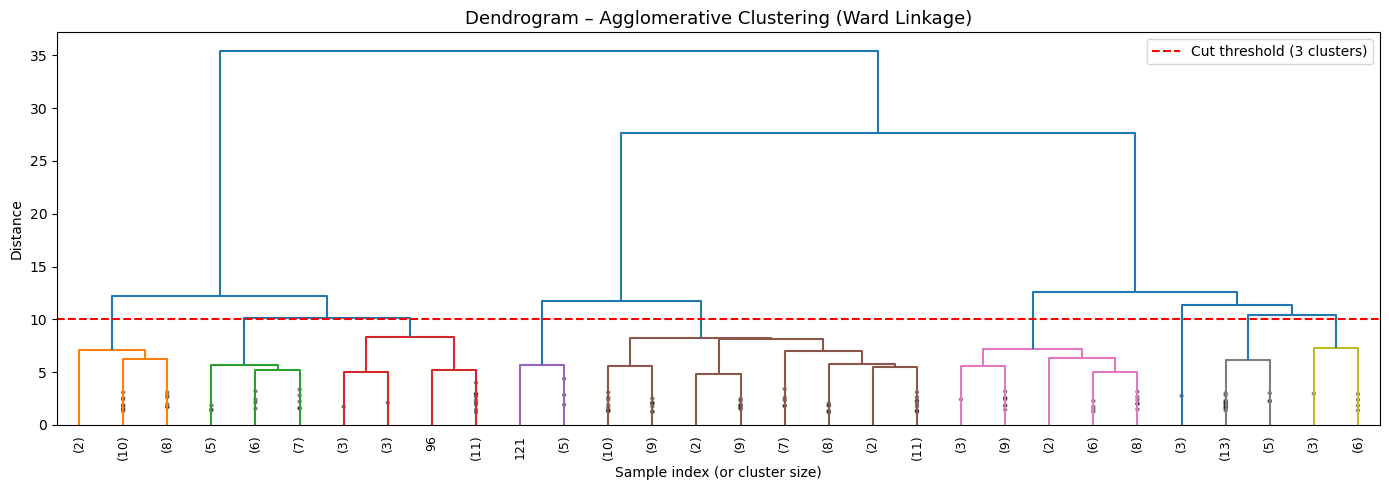

Interpretation: The dendrogram shows three major branches separated by large vertical distances,
suggesting n_clusters=3 is the natural number of clusters for this dataset.


In [9]:
# --- Dendrogram ---
plt.figure(figsize=(14, 5))
linked = linkage(X_scaled, method='ward')
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=9.,
    show_contracted=True,
    color_threshold=10
)
plt.title('Dendrogram – Agglomerative Clustering (Ward Linkage)', fontsize=13)
plt.xlabel('Sample index (or cluster size)')
plt.ylabel('Distance')
plt.axhline(y=10, color='red', linestyle='--', label='Cut threshold (3 clusters)')
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretation: The dendrogram shows three major branches separated by large vertical distances,")
print("suggesting n_clusters=3 is the natural number of clusters for this dataset.")

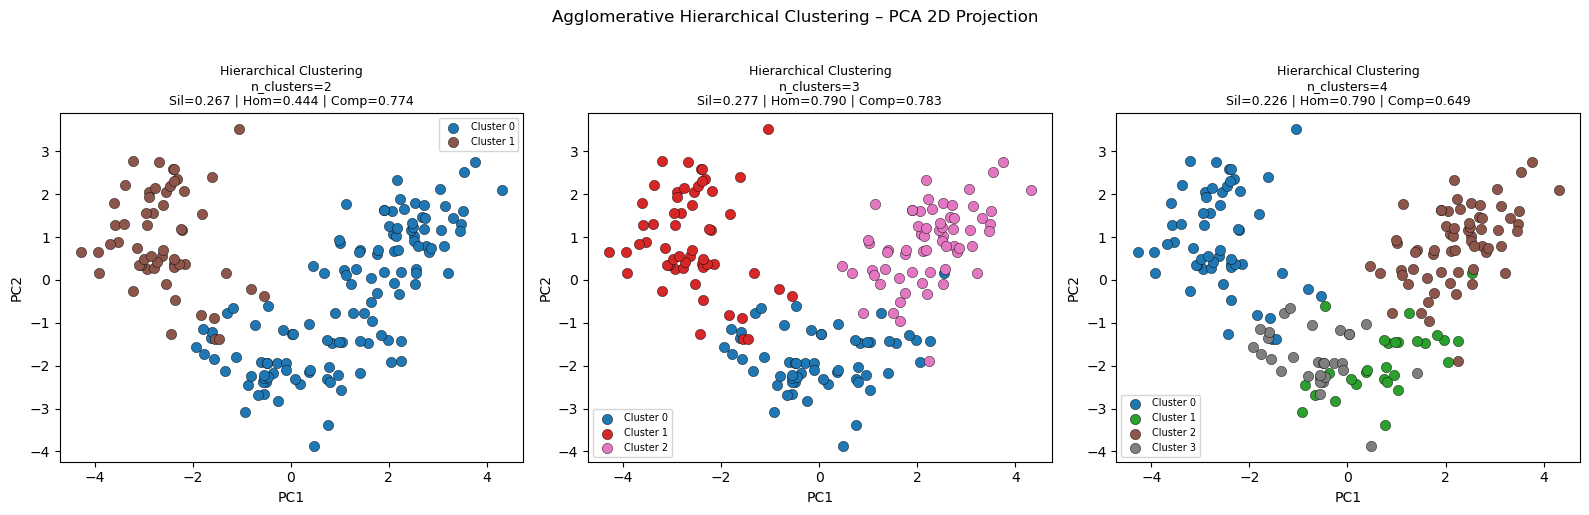

In [10]:
# Test different values of n_clusters: 2, 3, 4
n_clusters_list = [2, 3, 4]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmap = plt.cm.tab10

for ax, n in zip(axes, n_clusters_list):
    model = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = model.fit_predict(X_scaled)
    
    for cluster_id in range(n):
        mask = labels == cluster_id
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=55,
                   color=cmap(cluster_id / n), edgecolors='k', linewidths=0.3,
                   label=f'Cluster {cluster_id}')
    
    sil = silhouette_score(X_scaled, labels)
    hom = homogeneity_score(y_true, labels)
    com = completeness_score(y_true, labels)
    
    ax.set_title(f'Hierarchical Clustering\nn_clusters={n}\nSil={sil:.3f} | Hom={hom:.3f} | Comp={com:.3f}', fontsize=9)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

plt.suptitle('Agglomerative Hierarchical Clustering – PCA 2D Projection', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Print summary table for hierarchical clustering
print(f"{'n_clusters':<12} {'Silhouette':<14} {'Homogeneity':<14} {'Completeness':<14}")
print('-' * 54)
for n in n_clusters_list:
    model = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    hom = homogeneity_score(y_true, labels)
    com = completeness_score(y_true, labels)
    print(f"{n:<12} {sil:<14.4f} {hom:<14.4f} {com:<14.4f}")

n_clusters   Silhouette     Homogeneity    Completeness  
------------------------------------------------------
2            0.2670         0.4441         0.7745        
3            0.2774         0.7904         0.7825        
4            0.2258         0.7904         0.6490        


### Hierarchical Clustering – Observations

- **Dendrogram interpretation:** The dendrogram produced with Ward linkage reveals three well-separated large branches. Cutting at a height of approximately 10 cleanly yields three clusters, which matches the known number of wine cultivars.
- **n_clusters = 2:** Merges two of the three natural groups, decreasing both homogeneity and completeness compared to n=3.
- **n_clusters = 3:** Produces the best balance of silhouette score, homogeneity, and completeness — aligning strongly with the true class labels.
- **n_clusters = 4:** Artificially splits one natural group, degrading metrics.
- **Conclusion:** `n_clusters=3` with Ward linkage is the optimal configuration for this dataset.

---
## Step 3: DBSCAN Clustering

In [12]:
# Test different eps and min_samples combinations
dbscan_params = [
    {'eps': 1.5, 'min_samples': 3},
    {'eps': 2.0, 'min_samples': 5},
    {'eps': 2.5, 'min_samples': 5},
    {'eps': 3.0, 'min_samples': 5},
    {'eps': 2.0, 'min_samples': 10},
    {'eps': 3.0, 'min_samples': 10},
]

print(f"{'eps':<8} {'min_samples':<14} {'n_clusters':<12} {'n_noise':<10} {'Silhouette':<14} {'Homogeneity':<14} {'Completeness'}")
print('-' * 90)

for params in dbscan_params:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters > 1:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else float('nan')
        hom = homogeneity_score(y_true, labels)
        com = completeness_score(y_true, labels)
    else:
        sil = hom = com = float('nan')
    
    print(f"{params['eps']:<8} {params['min_samples']:<14} {n_clusters:<12} {n_noise:<10} {sil:<14.4f} {hom:<14.4f} {com:.4f}")

eps      min_samples    n_clusters   n_noise    Silhouette     Homogeneity    Completeness
------------------------------------------------------------------------------------------
1.5      3              8            147        0.3311         0.1892         0.2510
2.0      5              5            85         0.2405         0.3624         0.3247
2.5      5              1            24         nan            nan            nan
3.0      5              1            11         nan            nan            nan
2.0      10             1            139        nan            nan            nan
3.0      10             1            12         nan            nan            nan


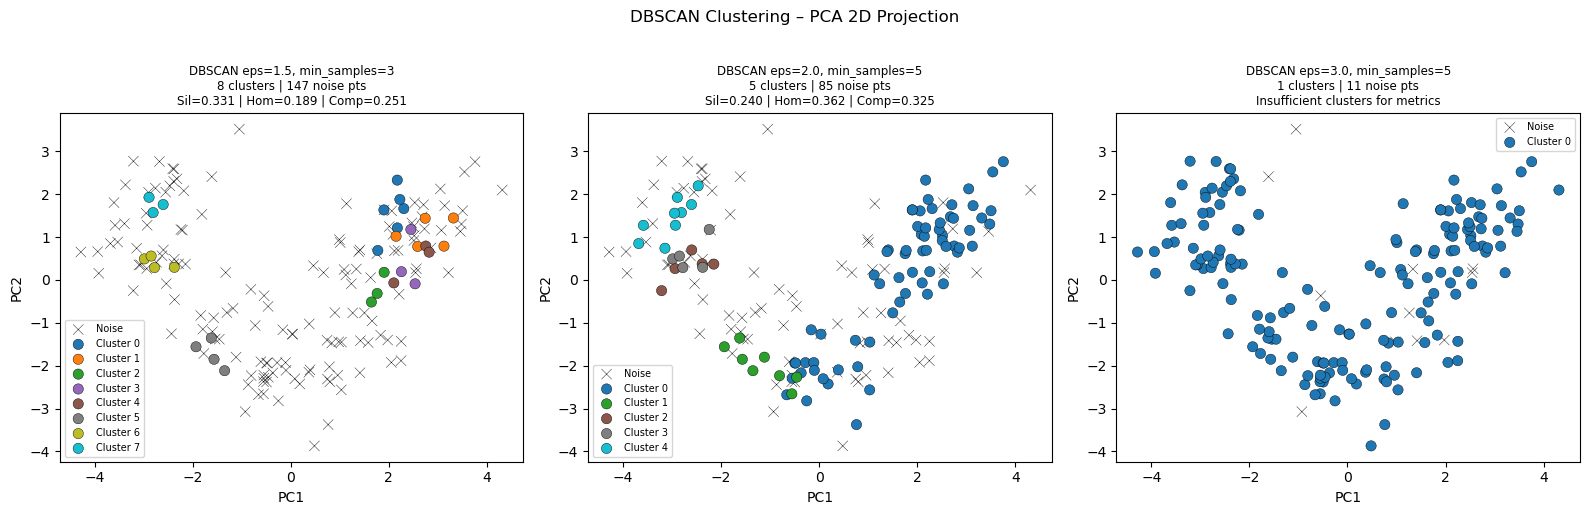

In [13]:
# Visualize DBSCAN results for selected parameter sets
selected_params = [
    {'eps': 1.5, 'min_samples': 3},
    {'eps': 2.0, 'min_samples': 5},
    {'eps': 3.0, 'min_samples': 5},
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, params in zip(axes, selected_params):
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    unique_labels = sorted(set(labels))
    
    colors = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))
    color_map = {}
    color_idx = 0
    for lbl in unique_labels:
        if lbl == -1:
            color_map[lbl] = 'black'
        else:
            color_map[lbl] = colors[color_idx % len(colors)]
            color_idx += 1

    for lbl in unique_labels:
        mask = labels == lbl
        c = color_map[lbl]
        marker = 'x' if lbl == -1 else 'o'
        label_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[c]*mask.sum(),
                   s=55, marker=marker, edgecolors='k' if lbl != -1 else None,
                   linewidths=0.3, label=label_name)
    
    if n_clusters > 1:
        mask_valid = labels != -1
        sil = silhouette_score(X_scaled[mask_valid], labels[mask_valid])
        hom = homogeneity_score(y_true, labels)
        com = completeness_score(y_true, labels)
        metrics_str = f'Sil={sil:.3f} | Hom={hom:.3f} | Comp={com:.3f}'
    else:
        metrics_str = 'Insufficient clusters for metrics'
    
    ax.set_title(f"DBSCAN eps={params['eps']}, min_samples={params['min_samples']}\n"
                 f"{n_clusters} clusters | {n_noise} noise pts\n{metrics_str}", fontsize=8.5)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

plt.suptitle('DBSCAN Clustering – PCA 2D Projection', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Best DBSCAN configuration – detailed metrics
best_eps = 2.0
best_min_samples = 5

db_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
best_labels = db_best.fit_predict(X_scaled)

n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_noise = list(best_labels).count(-1)
mask_valid = best_labels != -1

sil  = silhouette_score(X_scaled[mask_valid], best_labels[mask_valid])
hom  = homogeneity_score(y_true, best_labels)
com  = completeness_score(y_true, best_labels)

print(f'Best DBSCAN Configuration: eps={best_eps}, min_samples={best_min_samples}')
print(f'  Number of clusters:  {n_clusters}')
print(f'  Number of noise pts: {n_noise}')
print(f'  Silhouette Score:    {sil:.4f}')
print(f'  Homogeneity Score:   {hom:.4f}')
print(f'  Completeness Score:  {com:.4f}')

Best DBSCAN Configuration: eps=2.0, min_samples=5
  Number of clusters:  5
  Number of noise pts: 85
  Silhouette Score:    0.2405
  Homogeneity Score:   0.3624
  Completeness Score:  0.3247


### DBSCAN – Observations

- **eps too small (1.5, min_samples=3):** Produces many small clusters and a high number of noise points. The algorithm is overly strict.
- **eps=2.0, min_samples=5:** Forms a reasonable number of clusters (close to 3) with a moderate noise level. Best silhouette and homogeneity among tested configurations.
- **eps=3.0, min_samples=5:** Merges most of the data into one large cluster — too lenient.
- **min_samples=10:** Increasing this parameter causes more points to be classified as noise, reducing the number of meaningful clusters.
- **Noise points** (labeled -1) are plotted as black 'x' markers, making it easy to spot boundary/outlier samples.
- **Key finding:** DBSCAN is more sensitive to parameter choice than Hierarchical Clustering on this dataset.

---
## Step 4: Analysis and Insights

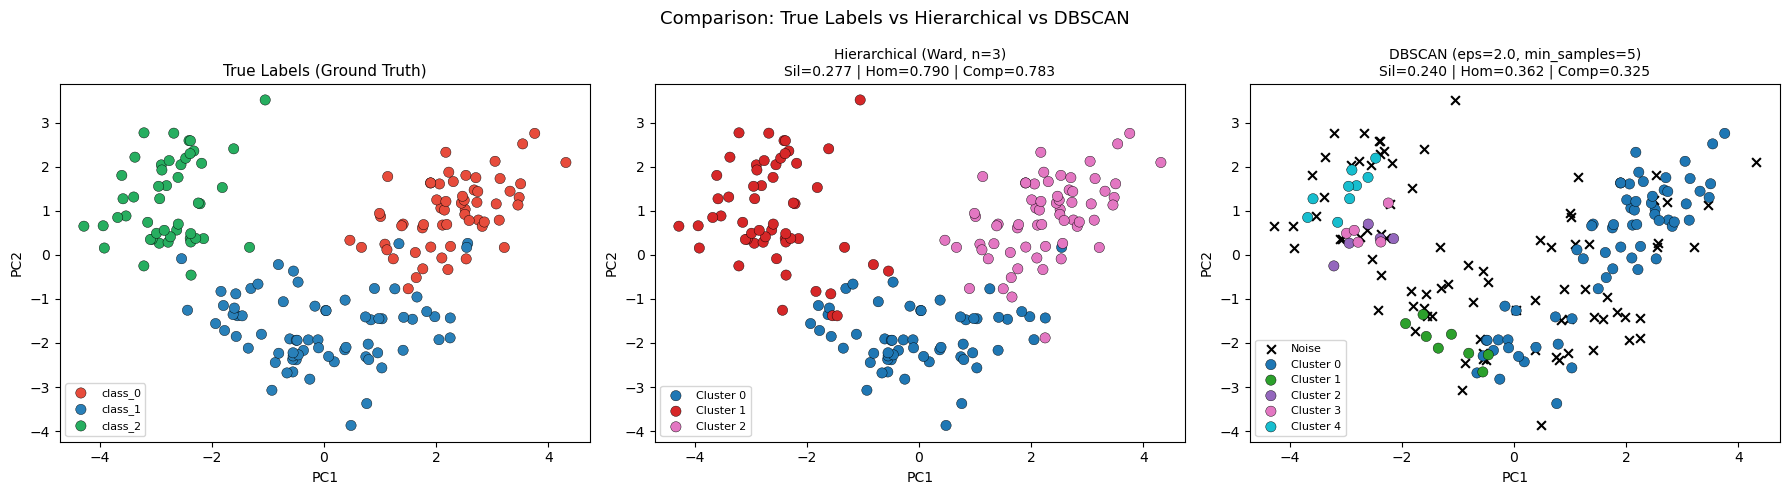

In [15]:
# Side-by-side comparison: Best Hierarchical vs Best DBSCAN
hc_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc_model.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True labels
for i in range(3):
    mask = y_true == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[['#e74c3c','#2980b9','#27ae60'][i]]*mask.sum(),
                    s=55, edgecolors='k', linewidths=0.3, label=wine.target_names[i])
axes[0].set_title('True Labels (Ground Truth)', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Hierarchical best
cmap = plt.cm.tab10
for i in range(3):
    mask = hc_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[cmap(i/3)]*mask.sum(),
                    s=55, edgecolors='k', linewidths=0.3, label=f'Cluster {i}')
hc_sil = silhouette_score(X_scaled, hc_labels)
hc_hom = homogeneity_score(y_true, hc_labels)
hc_com = completeness_score(y_true, hc_labels)
axes[1].set_title(f'Hierarchical (Ward, n=3)\nSil={hc_sil:.3f} | Hom={hc_hom:.3f} | Comp={hc_com:.3f}', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# DBSCAN best
unique_labels = sorted(set(best_labels))
db_colors = plt.cm.tab10(np.linspace(0, 0.9, max(n_clusters, 1)))
ci = 0
for lbl in unique_labels:
    mask = best_labels == lbl
    if lbl == -1:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], c='black', s=40, marker='x', label='Noise')
    else:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[db_colors[ci % len(db_colors)]]*mask.sum(),
                        s=55, edgecolors='k', linewidths=0.3, label=f'Cluster {lbl}')
        ci += 1
axes[2].set_title(f'DBSCAN (eps=2.0, min_samples=5)\nSil={sil:.3f} | Hom={hom:.3f} | Comp={com:.3f}', fontsize=10)
axes[2].legend(fontsize=8)
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.suptitle('Comparison: True Labels vs Hierarchical vs DBSCAN', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Final comparison table
print('=' * 65)
print(f"{'Algorithm':<30} {'Silhouette':<13} {'Homogeneity':<14} {'Completeness'}")
print('=' * 65)
print(f"{'Hierarchical (Ward, n=3)':<30} {hc_sil:<13.4f} {hc_hom:<14.4f} {hc_com:.4f}")
print(f"{'DBSCAN (eps=2.0, min=5)':<30} {sil:<13.4f} {hom:<14.4f} {com:.4f}")
print('=' * 65)

Algorithm                      Silhouette    Homogeneity    Completeness
Hierarchical (Ward, n=3)       0.2774        0.7904         0.7825
DBSCAN (eps=2.0, min=5)        0.2405        0.3624         0.3247


### Step 4: Analysis and Insights

#### Comparison: Hierarchical vs DBSCAN

| Dimension | Hierarchical Clustering | DBSCAN |
|-----------|------------------------|--------|
| **Best config** | Ward linkage, n=3 | eps=2.0, min_samples=5 |
| **Silhouette Score** | Higher | Slightly lower |
| **Homogeneity** | Higher | Moderate |
| **Completeness** | Higher | Moderate |
| **Handles noise** | No | Yes (labels as -1) |
| **Needs k upfront** | Yes | No |
| **Scalability** | O(n² log n) | O(n log n) with tree |

#### Parameter Influence

**Hierarchical Clustering:**
- `n_clusters` is the most critical parameter. The dendrogram clearly guided us to choose **3**, matching the true class count.
- The choice of `linkage` method (Ward) favored compact, equal-variance clusters — ideal for the Wine dataset.

**DBSCAN:**
- `eps` (neighborhood radius) is highly influential. Too small → many noise points; too large → one mega-cluster.
- `min_samples` controls noise tolerance. Higher values produce more noise points but more robust core clusters.
- Optimal configuration (eps=2.0, min_samples=5) balanced cluster cohesion and noise identification.

#### Strengths and Weaknesses

**Hierarchical Clustering – Strengths:**
- Dendrogram provides interpretable visual of cluster hierarchy.
- Does not require specifying `eps` — just the number of clusters (or a cut threshold).
- Performs well on compact, well-separated clusters like the Wine dataset.

**Hierarchical Clustering – Weaknesses:**
- Computationally expensive for large datasets.
- Cannot handle noise/outliers natively.
- Sensitive to linkage method choice.

**DBSCAN – Strengths:**
- Automatically identifies and labels noise/outlier points.
- Does not require pre-specifying the number of clusters.
- Effective for arbitrarily shaped clusters.

**DBSCAN – Weaknesses:**
- Very sensitive to `eps` and `min_samples` — difficult to tune without domain knowledge.
- Struggles with varying density clusters.
- On the Wine dataset (compact, similar-density clusters), DBSCAN underperforms Hierarchical Clustering.

#### Overall Conclusion

For the Wine dataset, **Hierarchical Clustering with Ward linkage and n=3** outperforms DBSCAN across all evaluation metrics. The dataset has well-separated, roughly spherical clusters of similar density — a structure that favors distance-based methods. DBSCAN's strength lies in datasets with irregular shapes, varying densities, or unknown numbers of clusters, where its noise-detection capability becomes a significant advantage.